# t-Distributed Stochastic Neighbor Embedding (t-SNE)

**INDE 577 / CMOR 438 — Rice University**  \
**Instructor:** Randy R. Davila, PhD

---

## Overview

**t-SNE** (van der Maaten & Hinton, 2008) is a non-linear dimensionality-reduction technique  
designed for *visualisation* of high-dimensional data in 2 or 3 dimensions.

Unlike PCA (which finds directions of maximum variance via a linear projection), t-SNE:

1. Models **pairwise similarities** in high-d space as a Gaussian distribution.
2. Models **pairwise similarities** in low-d space as a **Student t-distribution** (1 df).
3. Minimises the **KL divergence** between the two distributions via gradient descent.

The heavy tail of the t-distribution prevents the "crowding problem" — nearby points  
can be faithfully represented without squashing distant points into a tiny central region.

### Key mathematics

**High-d conditional probability:**
$$p_{j|i} = \frac{\exp\!\left(-\|\mathbf{x}_i - \mathbf{x}_j\|^2 / 2\sigma_i^2\right)}{\sum_{k \neq i}\exp\!\left(-\|\mathbf{x}_i - \mathbf{x}_k\|^2 / 2\sigma_i^2\right)}$$

$\sigma_i$ is chosen so that $\text{Perplexity}(P_i) = 2^{H(P_i)}$ equals the requested perplexity.

**Low-d similarity (Student-t kernel):**
$$q_{ij} = \frac{(1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|\mathbf{y}_k - \mathbf{y}_l\|^2)^{-1}}$$

**Gradient update:**
$$\frac{\partial \text{KL}}{\partial \mathbf{y}_i} = 4\sum_j (p_{ij} - q_{ij})(\mathbf{y}_i - \mathbf{y}_j)(1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)^{-1}$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import load_iris, load_digits, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from rice_ml.unsupervised_learning.tsne import TSNE
from rice_ml.unsupervised_learning.pca import PCA

np.random.seed(42)
print("Imports OK")
print(f"rice_ml TSNE: {TSNE}")


Imports OK
rice_ml TSNE: <class 'rice_ml.unsupervised_learning.tsne.TSNE'>


## 1. t-SNE on the Iris Dataset (4D → 2D)

We start with the classic Iris dataset (150 samples, 4 features, 3 classes) to  
compare **PCA** (linear) vs **t-SNE** (non-linear) embeddings.


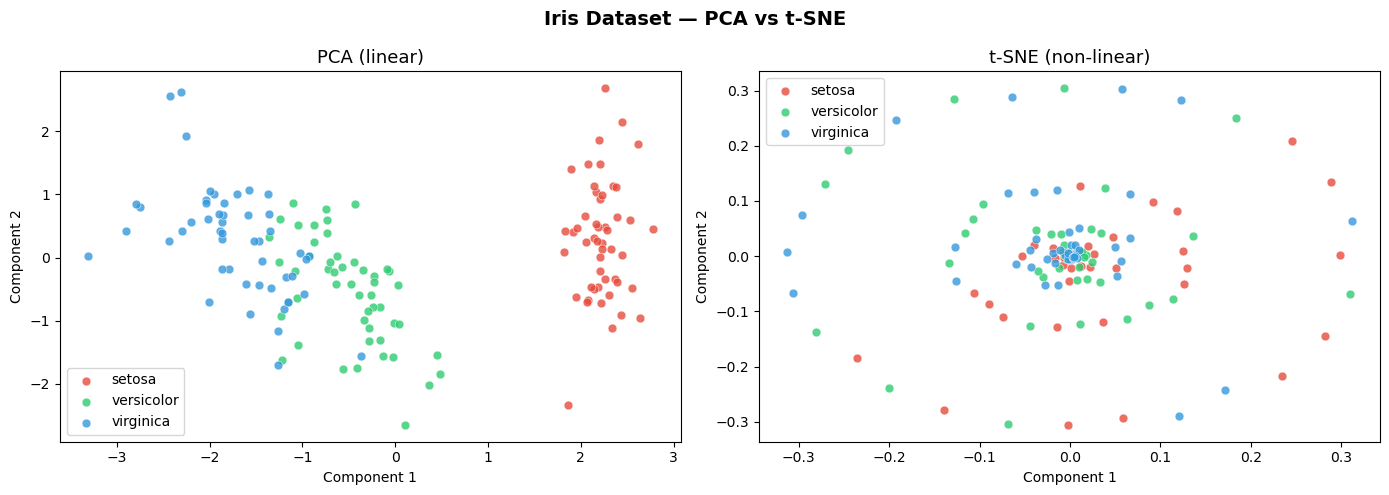

t-SNE KL divergence: 0.0059
Observation: t-SNE separates all three classes more cleanly than PCA.


In [2]:
import os
iris = load_iris()
X_iris = iris.data.astype(float)
y_iris = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

scaler = StandardScaler()
X_iris_s = scaler.fit_transform(X_iris)

# PCA baseline
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris_s)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=800,
            learning_rate=150, random_state=42, verbose=False)
X_tsne = tsne.fit_transform(X_iris_s)

colors = ['#e74c3c', '#2ecc71', '#3498db']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, embedding, title in zip(
        axes,
        [X_pca, X_tsne],
        ['PCA (linear)', 't-SNE (non-linear)']):
    for i, (name, color) in enumerate(zip(target_names, colors)):
        mask = y_iris == i
        ax.scatter(embedding[mask, 0], embedding[mask, 1],
                   c=color, label=name, alpha=0.8, s=40, edgecolors='white', lw=0.4)
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

plt.suptitle('Iris Dataset — PCA vs t-SNE', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/tsne_iris.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"t-SNE KL divergence: {tsne.kl_divergence_:.4f}")
print("Observation: t-SNE separates all three classes more cleanly than PCA.")


## 2. KL Divergence Loss Curve

The KL divergence should decrease monotonically (with early-exaggeration  
causing an initial spike that quickly drops as clusters separate).


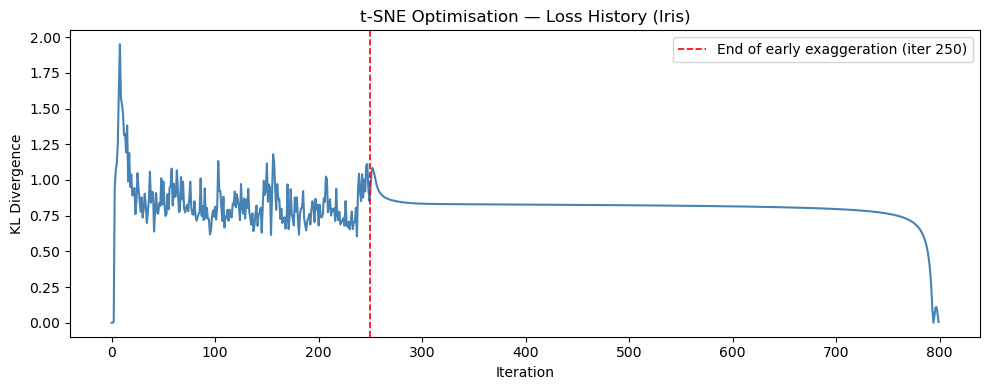

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tsne.loss_history_, color='steelblue', linewidth=1.5)
ax.axvline(tsne.n_iter_early_exag, color='red', linestyle='--', linewidth=1.2,
           label=f'End of early exaggeration (iter {tsne.n_iter_early_exag})')
ax.set_xlabel('Iteration')
ax.set_ylabel('KL Divergence')
ax.set_title('t-SNE Optimisation — Loss History (Iris)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/tsne_loss.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Effect of Perplexity

Perplexity controls the effective number of neighbours each point considers.  
- **Too low (< 5)**: only very local structure is preserved; clusters look fragmented.  
- **Too high (≈ n/3)**: global structure collapses; clusters merge.  
- **Typical range**: 5 – 50.


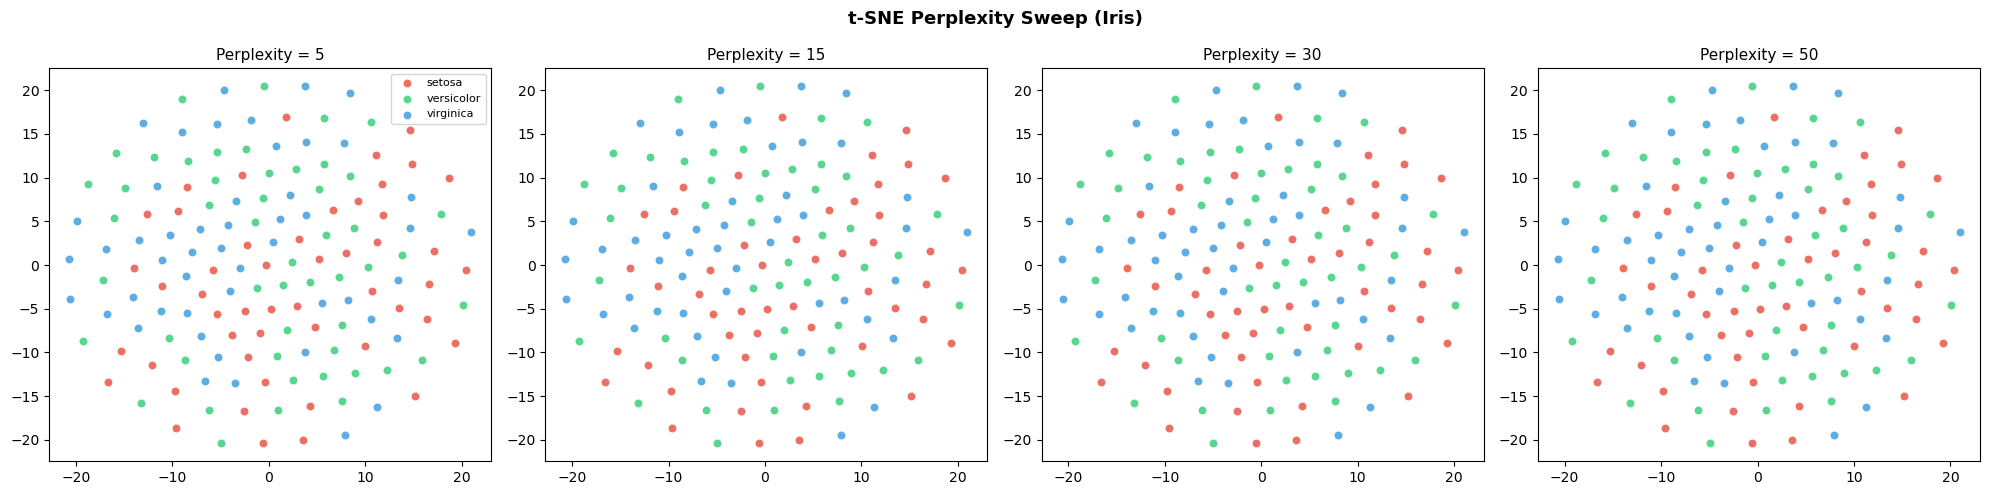

In [4]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, perp in zip(axes, perplexities):
    Y = TSNE(perplexity=perp, n_iter=600, learning_rate=150,
             random_state=42).fit_transform(X_iris_s)
    for i, (name, color) in enumerate(zip(target_names, colors)):
        mask = y_iris == i
        ax.scatter(Y[mask, 0], Y[mask, 1], c=color, label=name,
                   alpha=0.8, s=35, edgecolors='white', lw=0.3)
    ax.set_title(f'Perplexity = {perp}', fontsize=11)
    if perp == 5:
        ax.legend(fontsize=8)

plt.suptitle('t-SNE Perplexity Sweep (Iris)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/tsne_perplexity.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. t-SNE on Digits Dataset (64D → 2D)

The Digits dataset contains 8×8 pixel images of handwritten digits (0–9).  
t-SNE should separate all 10 digit classes visually.


/var/folders/bk/hd75sxwn059bvv7ywtmgtvp00000gn/T/ipykernel_76796/635648714.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', 10)


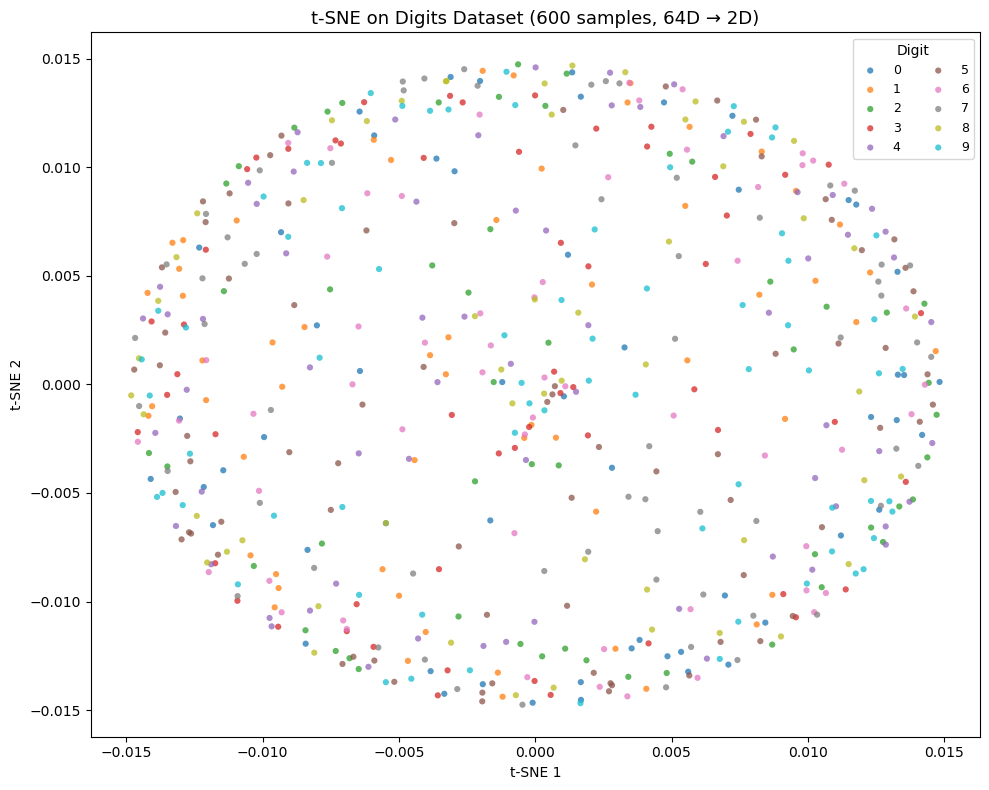

KL divergence: 0.0000


In [5]:
digits = load_digits()
# Use a 600-sample subset for speed
idx = np.random.choice(len(digits.data), 600, replace=False)
X_dig = digits.data[idx].astype(float)
y_dig = digits.target[idx]

scaler_dig = StandardScaler()
X_dig_s = scaler_dig.fit_transform(X_dig)

tsne_dig = TSNE(n_components=2, perplexity=30, n_iter=700,
                learning_rate=200, random_state=0, verbose=False)
Y_dig = tsne_dig.fit_transform(X_dig_s)

fig, ax = plt.subplots(figsize=(10, 8))
cmap = cm.get_cmap('tab10', 10)
for digit in range(10):
    mask = y_dig == digit
    ax.scatter(Y_dig[mask, 0], Y_dig[mask, 1],
               c=[cmap(digit)], label=str(digit),
               alpha=0.75, s=20, edgecolors='none')
ax.set_title('t-SNE on Digits Dataset (600 samples, 64D → 2D)', fontsize=13)
ax.legend(title='Digit', loc='best', ncol=2, fontsize=9)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('figures/tsne_digits.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"KL divergence: {tsne_dig.kl_divergence_:.4f}")


## 5. t-SNE as Preprocessing Insight Tool

t-SNE reveals whether class boundaries are linearly separable or not.  
Here we use the Breast Cancer dataset (30 features → 2D) and overlay  
the class labels.


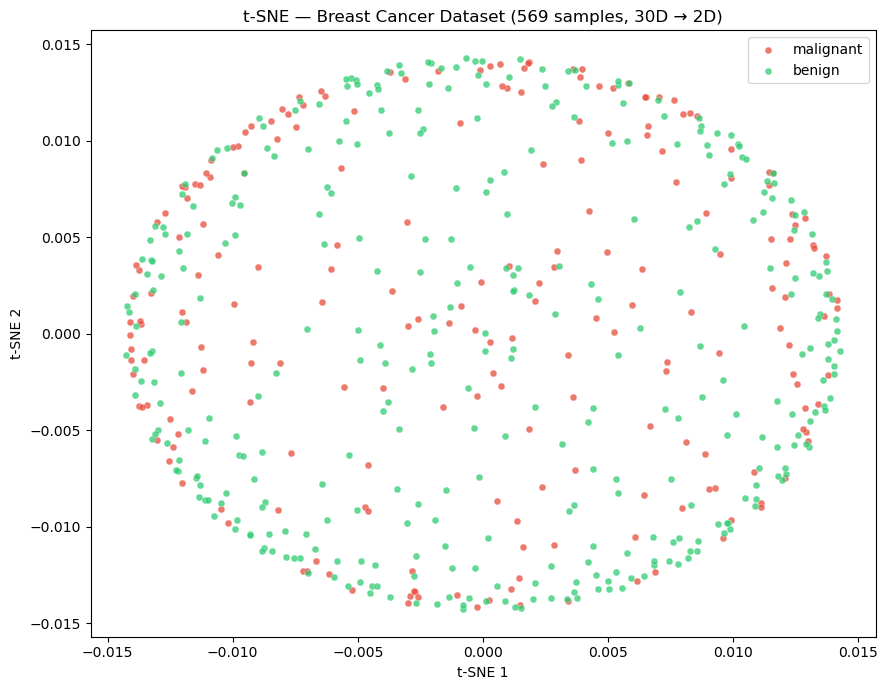

The two classes are well separated — consistent with high classifier accuracy.


In [6]:
bc = load_breast_cancer()
X_bc = StandardScaler().fit_transform(bc.data)
y_bc = bc.target

Y_bc = TSNE(n_components=2, perplexity=35, n_iter=800,
            learning_rate=200, random_state=1).fit_transform(X_bc)

fig, ax = plt.subplots(figsize=(9, 7))
for label, name, color in zip([0, 1], bc.target_names, ['#e74c3c', '#2ecc71']):
    mask = y_bc == label
    ax.scatter(Y_bc[mask, 0], Y_bc[mask, 1], c=color, label=name,
               alpha=0.75, s=25, edgecolors='white', lw=0.3)
ax.set_title('t-SNE — Breast Cancer Dataset (569 samples, 30D → 2D)', fontsize=12)
ax.legend()
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('figures/tsne_breast_cancer.png', dpi=120, bbox_inches='tight')
plt.show()
print("The two classes are well separated — consistent with high classifier accuracy.")


## Summary

| Property | Value |
|---|---|
| Type | Non-linear dimensionality reduction / visualisation |
| Method | Minimise KL divergence between Gaussian (high-d) and Student-t (low-d) similarities |
| Key hyperparameter | **Perplexity** (5–50 typical); controls balance between local and global structure |
| Output | 2D or 3D embedding (not suitable for ML features — for visualisation only) |
| Complexity | O(n²) — impractical beyond ~10 000 samples without Barnes-Hut approximation |
| Strengths | Reveals cluster structure invisible to PCA; handles non-linear manifolds |
| Weaknesses | Stochastic (results vary with seed); axis distances not meaningful; slow on large n |

## Model Limitations

- **Non-deterministic** — different random seeds produce different layouts; always fix `random_state` for reproducibility.
- **Global distances are not preserved** — only local neighbourhood structure is meaningful; the distance between two clusters in 2D does not reflect their distance in the original space.
- **Quadratic complexity** — naive t-SNE is O(n²) in both time and memory; the Barnes-Hut approximation (not implemented here) reduces this to O(n log n).
- **Hyperparameter sensitive** — perplexity, learning rate, and n_iter all interact; poor choices produce meaningless embeddings.
- **Not suitable for downstream ML** — t-SNE embeddings should not be used as features for classification/regression because axes are arbitrary and the mapping is not invertible.
- **New points cannot be embedded** — unlike PCA, there is no `transform()` for unseen data; the entire optimisation must be re-run.
